# 8.2 First-Order Optimization Methods

This notebook explores **first-order optimization methods** — algorithms that use gradient information to iteratively minimize an objective function. We cover gradient descent, step size selection, convergence rates, and momentum methods.

## Real-World Scenario

A biotech company is developing a **drug dose-response model**. Given experimental data on drug concentrations and observed cell viability, they need to fit a nonlinear model by minimizing a loss function. We'll use this as our running example to compare different first-order optimizers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. The Optimization Problem

We want to find parameters $\boldsymbol{\theta}^*$ that minimize a **loss function** $\mathcal{L}(\boldsymbol{\theta})$:

$$\boldsymbol{\theta}^* \in \operatorname*{argmin}_{\boldsymbol{\theta} \in \Theta} \mathcal{L}(\boldsymbol{\theta})$$

First-order methods use the **gradient** $\mathbf{g}_t = \nabla \mathcal{L}(\boldsymbol{\theta}_t)$ to iteratively update the parameters:

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t + \eta_t \mathbf{d}_t$$

where $\eta_t$ is the **step size** (learning rate) and $\mathbf{d}_t$ is a **descent direction**.

### Our Test Problem: A Quadratic Loss

We start with a 2D quadratic to build intuition:

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2} \boldsymbol{\theta}^\top \mathbf{A} \boldsymbol{\theta} + \mathbf{b}^\top \boldsymbol{\theta} + c$$

For this function, the gradient is $\mathbf{g} = \mathbf{A}\boldsymbol{\theta} + \mathbf{b}$, and the unique minimum is at $\boldsymbol{\theta}^* = -\mathbf{A}^{-1}\mathbf{b}$.

In [2]:
# Define a 2D quadratic objective
# L(theta) = 0.5 * (theta1^2 - theta2)^2 + 0.5 * (theta1 - 1)^2
# This is the Rosenbrock-like function from the textbook (Eq. 8.19)
A = np.array([[2.0, -1.0],
              [-1.0, 1.0]])
b = np.array([-1.0, 0.0])
c = 0.5

# Optimal solution
theta_star = -np.linalg.solve(A, b)

# Eigenvalues determine the condition number
eigvals = np.linalg.eigvalsh(A)
kappa = eigvals.max() / eigvals.min()

print(f"Matrix A:\n{A}")
print(f"\nEigenvalues: {eigvals}")
print(f"Condition number κ = {kappa:.2f}")
print(f"Optimal θ* = {theta_star}")
print(f"Optimal loss = {0.5 * theta_star @ A @ theta_star + b @ theta_star + c:.4f}")

Matrix A:
[[ 2. -1.]
 [-1.  1.]]

Eigenvalues: [0.38196601 2.61803399]
Condition number κ = 6.85
Optimal θ* = [1. 1.]
Optimal loss = 0.0000


/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/1914872478.py:29: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/1914872478.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/christophe/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christophe/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


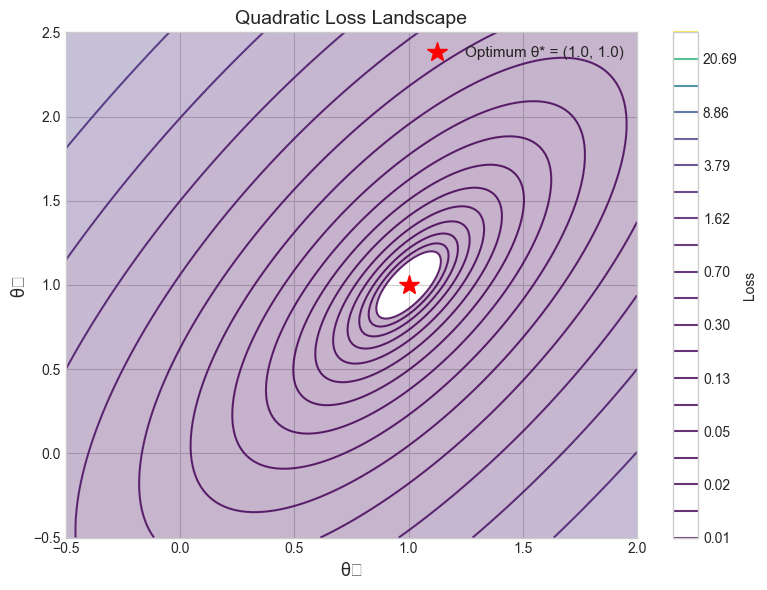

In [3]:
def quadratic_loss(theta, A, b, c):
    """Compute L(theta) = 0.5 * theta^T A theta + b^T theta + c."""
    return 0.5 * theta @ A @ theta + b @ theta + c

def quadratic_grad(theta, A, b):
    """Compute gradient: g = A theta + b."""
    return A @ theta + b

# Create contour plot data
t1 = np.linspace(-0.5, 2.0, 200)
t2 = np.linspace(-0.5, 2.5, 200)
T1, T2 = np.meshgrid(t1, t2)
Z = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        theta_ij = np.array([T1[i, j], T2[i, j]])
        Z[i, j] = quadratic_loss(theta_ij, A, b, c)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.logspace(-2, 1.5, 20)
cs = ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.8)
ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.3)
ax.plot(*theta_star, 'r*', markersize=15, label=f'Optimum θ* = ({theta_star[0]:.1f}, {theta_star[1]:.1f})')
ax.set_xlabel('θ₁', fontsize=13)
ax.set_ylabel('θ₂', fontsize=13)
ax.set_title('Quadratic Loss Landscape', fontsize=14)
ax.legend(fontsize=11)
plt.colorbar(cs, ax=ax, label='Loss')
plt.tight_layout()
plt.show()

## 2. Steepest Descent

### Descent Directions

A direction $\mathbf{d}$ is a **descent direction** if moving along it decreases the loss. Formally, there must exist $\eta_{\max} > 0$ such that:

$$\mathcal{L}(\boldsymbol{\theta} + \eta \mathbf{d}) < \mathcal{L}(\boldsymbol{\theta}) \quad \text{for all } 0 < \eta < \eta_{\max}$$

This holds whenever the angle between $\mathbf{d}$ and $-\mathbf{g}_t$ is less than 90°, i.e., $\mathbf{d}^\top \mathbf{g}_t < 0$.

### Steepest Descent

The simplest choice is **steepest descent**: $\mathbf{d}_t = -\mathbf{g}_t$. The update rule becomes:

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t \nabla \mathcal{L}(\boldsymbol{\theta}_t)$$

The gradient points in the direction of steepest *increase*, so its negative points downhill.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/844159693.py:28: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/844159693.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


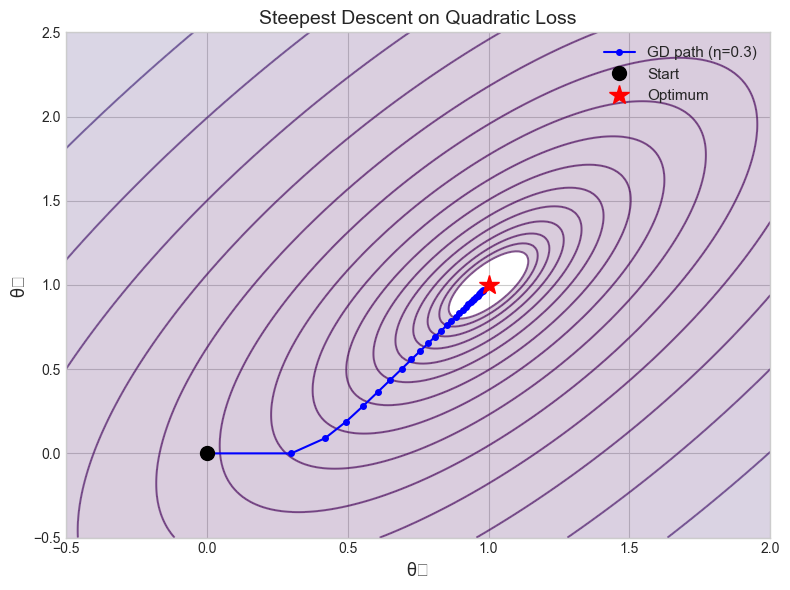

After 30 steps: θ = [0.9812, 0.9696]
Distance to optimum: 0.035733


In [4]:
def gradient_descent(grad_fn, theta0, lr, n_steps, **kwargs):
    """Run gradient descent with a fixed learning rate."""
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        theta = theta - lr * g
        path.append(theta.copy())
    return np.array(path)

# Run steepest descent with a good step size
theta0 = np.array([0.0, 0.0])
path_gd = gradient_descent(quadratic_grad, theta0, lr=0.3, n_steps=30, A=A, b=b)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.6)
ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.2)

ax.plot(path_gd[:, 0], path_gd[:, 1], 'b.-', markersize=8, linewidth=1.5, label='GD path (η=0.3)')
ax.plot(*theta0, 'ko', markersize=10, label='Start')
ax.plot(*theta_star, 'r*', markersize=15, label='Optimum')

ax.set_xlabel('θ₁', fontsize=13)
ax.set_ylabel('θ₂', fontsize=13)
ax.set_title('Steepest Descent on Quadratic Loss', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"After 30 steps: θ = [{path_gd[-1, 0]:.4f}, {path_gd[-1, 1]:.4f}]")
print(f"Distance to optimum: {np.linalg.norm(path_gd[-1] - theta_star):.6f}")

## 3. Step Size (Learning Rate)

The step size $\eta_t$ critically affects convergence. The textbook illustrates this clearly:

- **Too small** ($\eta \ll 1$): Convergence is very slow
- **Too large** ($\eta$ near the stability limit): Oscillation and possible divergence
- **Just right**: Fast, stable convergence

### Stability Condition for Quadratics

For $\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2}\boldsymbol{\theta}^\top\mathbf{A}\boldsymbol{\theta} + \mathbf{b}^\top\boldsymbol{\theta} + c$ with $\mathbf{A} \succeq 0$, steepest descent converges iff:

$$\eta < \frac{2}{\lambda_{\max}(\mathbf{A})}$$

where $\lambda_{\max}$ is the largest eigenvalue of $\mathbf{A}$.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/1373266679.py:30: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/1373266679.py:30: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


Maximum stable step size: η < 0.764
(Since λ_max = 2.618)



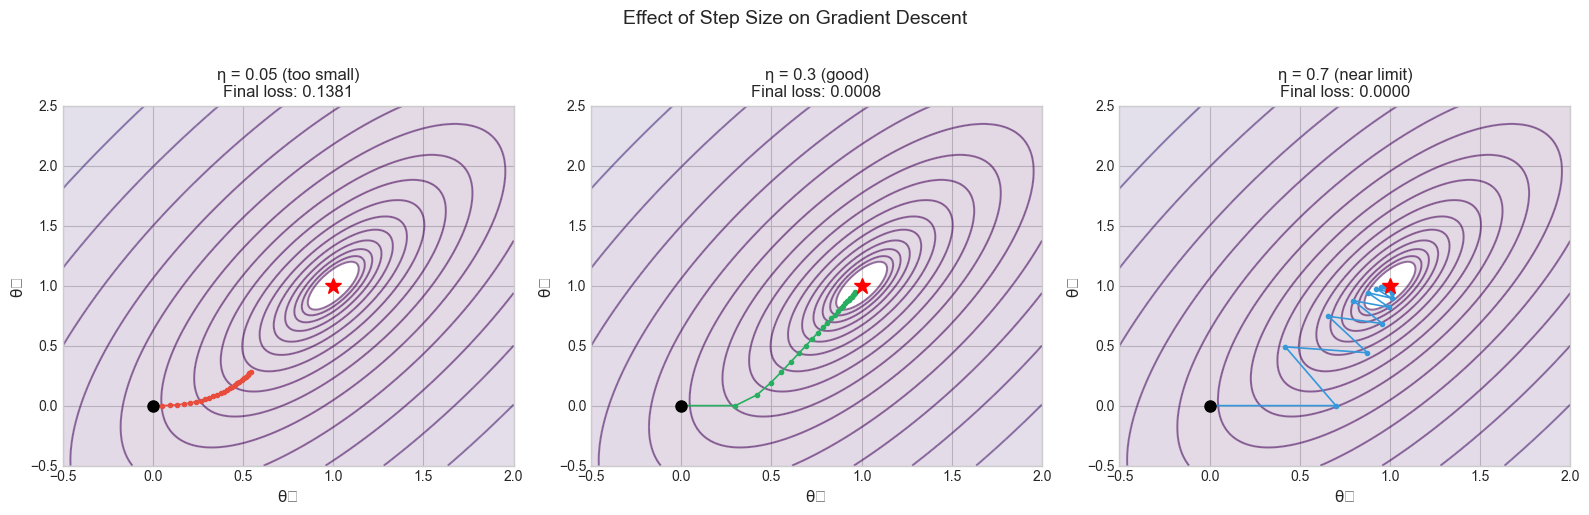

In [5]:
# Demonstrate effect of step size
eta_max = 2.0 / eigvals.max()
print(f"Maximum stable step size: η < {eta_max:.3f}")
print(f"(Since λ_max = {eigvals.max():.3f})\n")

step_sizes = [0.05, 0.3, 0.7]
labels = ['η = 0.05 (too small)', 'η = 0.3 (good)', 'η = 0.7 (near limit)']
colors = ['#e74c3c', '#27ae60', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (lr, label, color) in enumerate(zip(step_sizes, labels, colors)):
    ax = axes[idx]
    ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)
    
    path = gradient_descent(quadratic_grad, theta0, lr=lr, n_steps=25, A=A, b=b)
    ax.plot(path[:, 0], path[:, 1], '.-', color=color, markersize=6, linewidth=1.2)
    ax.plot(*theta0, 'ko', markersize=8)
    ax.plot(*theta_star, 'r*', markersize=12)
    
    final_loss = quadratic_loss(path[-1], A, b, c)
    ax.set_title(f'{label}\nFinal loss: {final_loss:.4f}', fontsize=12)
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_xlim(-0.5, 2.0)
    ax.set_ylim(-0.5, 2.5)

plt.suptitle('Effect of Step Size on Gradient Descent', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

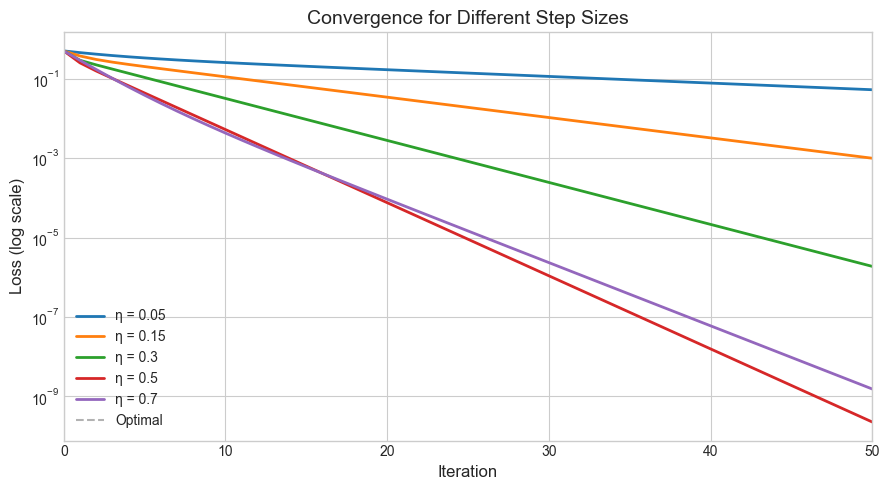

In [6]:
# Loss curves for different step sizes
fig, ax = plt.subplots(figsize=(9, 5))

step_sizes_full = [0.05, 0.15, 0.3, 0.5, 0.7]
for lr in step_sizes_full:
    path = gradient_descent(quadratic_grad, theta0, lr=lr, n_steps=50, A=A, b=b)
    losses = [quadratic_loss(p, A, b, c) for p in path]
    ax.semilogy(losses, linewidth=2, label=f'η = {lr}')

ax.axhline(quadratic_loss(theta_star, A, b, c), color='k', linestyle='--', alpha=0.3, label='Optimal')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Convergence for Different Step Sizes', fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, 50)
plt.tight_layout()
plt.show()

## 4. Line Search

Rather than picking a fixed step size, we can find the **optimal step size** at each iteration by solving a 1D minimization problem:

$$\eta_t = \operatorname*{argmin}_{\eta > 0} \mathcal{L}(\boldsymbol{\theta}_t + \eta \mathbf{d}_t)$$

This is called **line search** since we search along the line defined by $\mathbf{d}_t$.

### Exact Line Search for Quadratics

For the quadratic loss with descent direction $\mathbf{d}_t = -\mathbf{g}_t$, the optimal step size is:

$$\eta = -\frac{\mathbf{d}^\top(\mathbf{A}\boldsymbol{\theta} + \mathbf{b})}{\mathbf{d}^\top \mathbf{A} \mathbf{d}} = \frac{\mathbf{g}^\top \mathbf{g}}{\mathbf{g}^\top \mathbf{A} \mathbf{g}}$$

### Backtracking Line Search (Armijo)

For general (non-quadratic) functions, we use the **Armijo backtracking** method: start with a large step size and reduce it by a factor $0 < \rho < 1$ until the **Armijo-Goldstein condition** is satisfied:

$$\mathcal{L}(\boldsymbol{\theta}_t + \eta \mathbf{d}_t) \leq \mathcal{L}(\boldsymbol{\theta}_t) + c \, \eta \, \mathbf{d}_t^\top \nabla\mathcal{L}(\boldsymbol{\theta}_t)$$

where $c \in (0, 1)$ is a small constant (typically $c = 10^{-4}$).

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3882518263.py:67: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3882518263.py:67: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


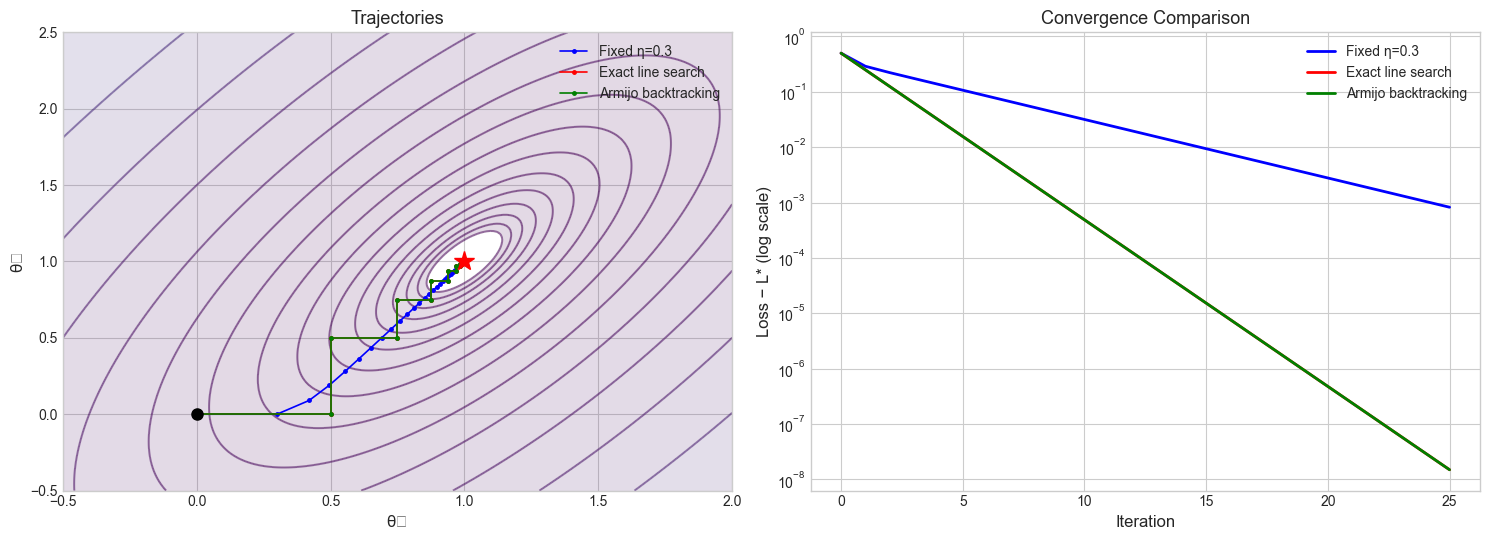

Note the characteristic zig-zag pattern of steepest descent with exact line search.
Each step is orthogonal to the previous one (since the gradient at the new point
must be perpendicular to the old search direction for the line search to be optimal).


In [7]:
def gd_exact_line_search(grad_fn, theta0, n_steps, A, b):
    """Gradient descent with exact line search for quadratic objectives."""
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_steps):
        g = grad_fn(theta, A=A, b=b)
        # Exact line search: η = g^T g / (g^T A g)
        eta = (g @ g) / (g @ A @ g)
        theta = theta - eta * g
        path.append(theta.copy())
    return np.array(path)

def gd_backtracking(loss_fn, grad_fn, theta0, n_steps, A, b, c_quad,
                     rho=0.5, c_armijo=1e-4, eta_init=1.0):
    """Gradient descent with Armijo backtracking line search."""
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_steps):
        g = grad_fn(theta, A=A, b=b)
        d = -g  # descent direction
        eta = eta_init
        current_loss = loss_fn(theta, A=A, b=b, c=c_quad)
        # Backtrack until Armijo condition is satisfied
        while loss_fn(theta + eta * d, A=A, b=b, c=c_quad) > current_loss + c_armijo * eta * (d @ g):
            eta *= rho
        theta = theta + eta * d
        path.append(theta.copy())
    return np.array(path)

# Compare fixed step size vs line search
path_fixed = gradient_descent(quadratic_grad, theta0, lr=0.3, n_steps=25, A=A, b=b)
path_exact = gd_exact_line_search(quadratic_grad, theta0, n_steps=25, A=A, b=b)
path_armijo = gd_backtracking(quadratic_loss, quadratic_grad, theta0, n_steps=25, A=A, b=b, c_quad=c)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: trajectories
ax = axes[0]
ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)
ax.plot(path_fixed[:, 0], path_fixed[:, 1], 'b.-', markersize=5, linewidth=1.2, label='Fixed η=0.3')
ax.plot(path_exact[:, 0], path_exact[:, 1], 'r.-', markersize=5, linewidth=1.2, label='Exact line search')
ax.plot(path_armijo[:, 0], path_armijo[:, 1], 'g.-', markersize=5, linewidth=1.2, label='Armijo backtracking')
ax.plot(*theta0, 'ko', markersize=8)
ax.plot(*theta_star, 'r*', markersize=15)
ax.set_xlabel('θ₁', fontsize=12)
ax.set_ylabel('θ₂', fontsize=12)
ax.set_title('Trajectories', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.5, 2.5)

# Right: loss curves
ax = axes[1]
opt_loss = quadratic_loss(theta_star, A, b, c)
for path, label, color in [(path_fixed, 'Fixed η=0.3', 'blue'), 
                            (path_exact, 'Exact line search', 'red'),
                            (path_armijo, 'Armijo backtracking', 'green')]:
    losses = [quadratic_loss(p, A, b, c) for p in path]
    ax.semilogy(np.array(losses) - opt_loss + 1e-16, linewidth=2, color=color, label=label)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss − L* (log scale)', fontsize=12)
ax.set_title('Convergence Comparison', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Note the characteristic zig-zag pattern of steepest descent with exact line search.")
print("Each step is orthogonal to the previous one (since the gradient at the new point")
print("must be perpendicular to the old search direction for the line search to be optimal).")

## 5. Convergence Rate and the Condition Number

For convex problems with bounded Lipschitz gradient, gradient descent converges at a **linear rate**:

$$|\mathcal{L}(\boldsymbol{\theta}_{t+1}) - \mathcal{L}(\boldsymbol{\theta}_*)| \leq \mu \, |\mathcal{L}(\boldsymbol{\theta}_t) - \mathcal{L}(\boldsymbol{\theta}_*)|$$

For steepest descent with exact line search on a quadratic, the rate is:

$$\mu = \left(\frac{\kappa - 1}{\kappa + 1}\right)^2$$

where $\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$ is the **condition number** of $\mathbf{A}$.

- **Small $\kappa$ (well-conditioned)**: The loss contours are nearly circular → fast convergence
- **Large $\kappa$ (ill-conditioned)**: The contours are elongated ellipses → slow zig-zag convergence

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3882518263.py:8: RuntimeWarning: invalid value encountered in scalar divide
  eta = (g @ g) / (g @ A @ g)
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3550788986.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3550788986.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


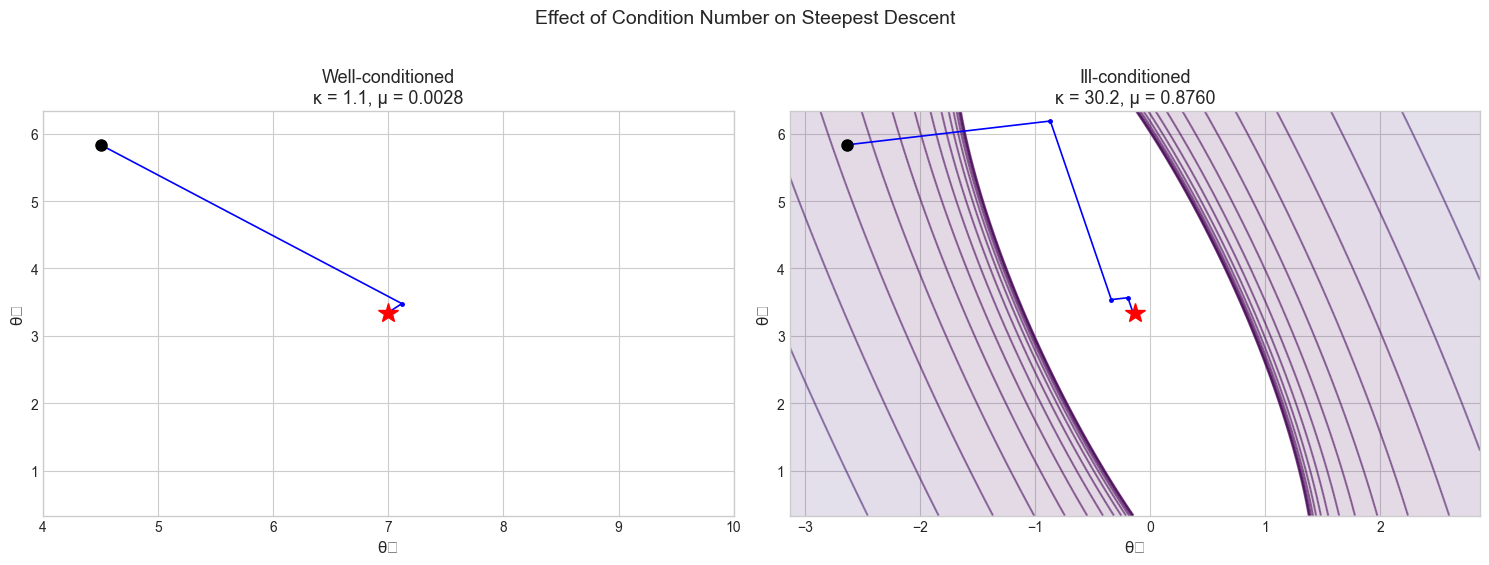

Left: Nearly circular contours → direct path to optimum
Right: Elongated contours → characteristic zig-zag pattern


In [8]:
# Compare well-conditioned vs ill-conditioned problems
A_good = np.array([[2.0, 0.0],
                    [0.0, 1.8]])  # κ ≈ 1.1

A_bad = np.array([[20.0, 5.0],
                   [5.0, 2.0]])   # κ ≈ 30

b_both = np.array([-14.0, -6.0])

configs = [
    (A_good, b_both, 'Well-conditioned'),
    (A_bad, b_both, 'Ill-conditioned'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for idx, (A_i, b_i, title) in enumerate(configs):
    ax = axes[idx]
    eigs = np.linalg.eigvalsh(A_i)
    kappa_i = eigs.max() / eigs.min()
    mu_i = ((kappa_i - 1) / (kappa_i + 1))**2
    theta_opt = -np.linalg.solve(A_i, b_i)
    
    # Create contours centered on optimum
    t1_i = np.linspace(theta_opt[0] - 3, theta_opt[0] + 3, 200)
    t2_i = np.linspace(theta_opt[1] - 3, theta_opt[1] + 3, 200)
    T1_i, T2_i = np.meshgrid(t1_i, t2_i)
    Z_i = np.zeros_like(T1_i)
    for i in range(T1_i.shape[0]):
        for j in range(T1_i.shape[1]):
            th = np.array([T1_i[i, j], T2_i[i, j]])
            Z_i[i, j] = quadratic_loss(th, A_i, b_i, 0)
    
    levels_i = np.logspace(-1, 3, 20)
    ax.contour(T1_i, T2_i, Z_i, levels=levels_i, cmap='viridis', alpha=0.5)
    ax.contourf(T1_i, T2_i, Z_i, levels=levels_i, cmap='viridis', alpha=0.15)
    
    # Run exact line search GD
    start = theta_opt + np.array([-2.5, 2.5])
    path_i = gd_exact_line_search(quadratic_grad, start, n_steps=30, A=A_i, b=b_i)
    ax.plot(path_i[:, 0], path_i[:, 1], 'b.-', markersize=5, linewidth=1.2)
    ax.plot(*start, 'ko', markersize=8)
    ax.plot(*theta_opt, 'r*', markersize=15)
    
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_title(f'{title}\nκ = {kappa_i:.1f}, μ = {mu_i:.4f}', fontsize=13)

plt.suptitle('Effect of Condition Number on Steepest Descent', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Left: Nearly circular contours → direct path to optimum")
print("Right: Elongated contours → characteristic zig-zag pattern")

## 6. Momentum Methods

Gradient descent can be very slow along flat regions or in narrow valleys. **Momentum methods** accelerate convergence by accumulating past gradient information.

### 6.1 Heavy Ball Momentum

The **heavy ball** method (Polyak, 1964) adds a momentum term that acts like a ball rolling downhill with inertia:

$$\mathbf{m}_t = \beta \mathbf{m}_{t-1} + \mathbf{g}_{t-1}$$
$$\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \eta_t \mathbf{m}_t$$

The momentum $\mathbf{m}_t$ is an **exponentially weighted moving average** of past gradients:

$$\mathbf{m}_t = \sum_{\tau=0}^{t-1} \beta^\tau \mathbf{g}_{t-\tau-1}$$

If all gradients are constant $\mathbf{g}$, the effective step becomes $\frac{1}{1-\beta}$ times larger. For $\beta = 0.9$, this is a 10× amplification.

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/190937136.py:38: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/190937136.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


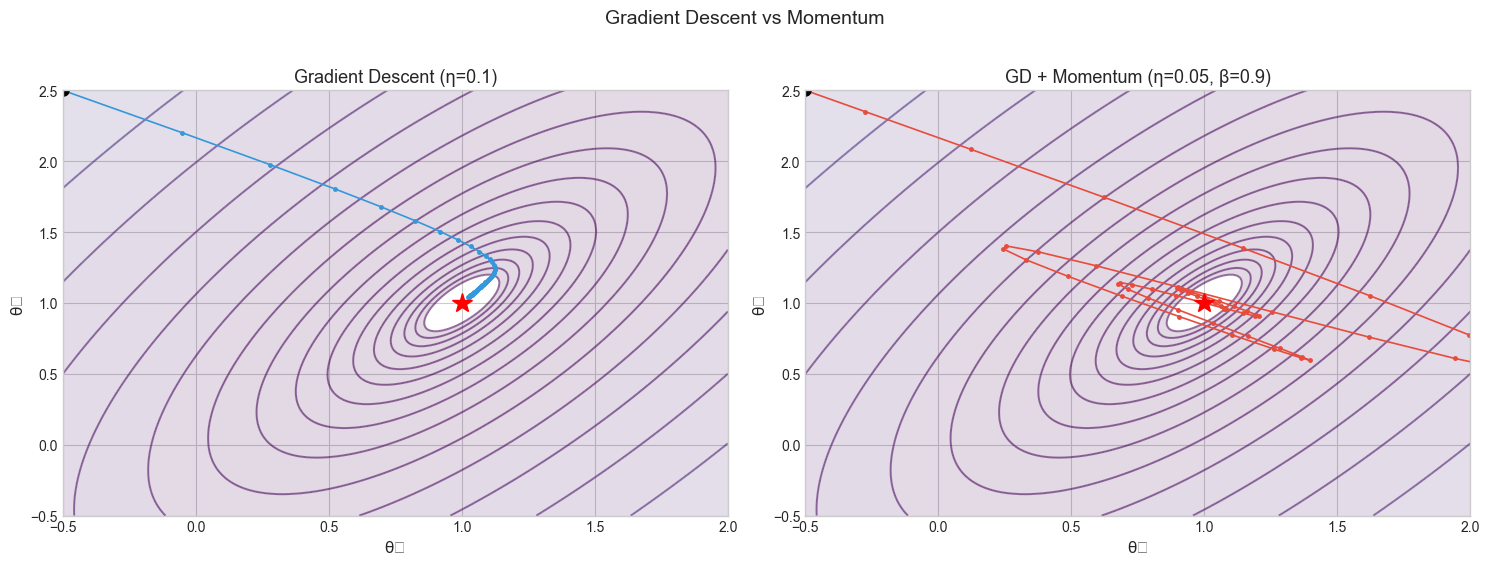

In [9]:
def gd_momentum(grad_fn, theta0, lr, beta, n_steps, **kwargs):
    """Gradient descent with heavy ball momentum."""
    theta = theta0.copy()
    m = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        m = beta * m + g
        theta = theta - lr * m
        path.append(theta.copy())
    return np.array(path)

# Compare GD vs GD+Momentum on ill-conditioned problem
theta0_mom = theta_star + np.array([-1.5, 1.5])

path_gd_plain = gradient_descent(quadratic_grad, theta0_mom, lr=0.1, n_steps=60, A=A, b=b)
path_gd_mom = gd_momentum(quadratic_grad, theta0_mom, lr=0.05, beta=0.9, n_steps=60, A=A, b=b)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax_idx, (path_i, label, color) in enumerate([
    (path_gd_plain, 'Gradient Descent (η=0.1)', '#3498db'),
    (path_gd_mom, 'GD + Momentum (η=0.05, β=0.9)', '#e74c3c')
]):
    ax = axes[ax_idx]
    ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)
    ax.plot(path_i[:, 0], path_i[:, 1], '.-', color=color, markersize=5, linewidth=1.2)
    ax.plot(*theta0_mom, 'ko', markersize=8)
    ax.plot(*theta_star, 'r*', markersize=15)
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.set_xlim(-0.5, 2.0)
    ax.set_ylim(-0.5, 2.5)

plt.suptitle('Gradient Descent vs Momentum', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Nesterov Accelerated Gradient

The **Nesterov accelerated gradient** (NAG) method improves on standard momentum with a "look-ahead" step. Instead of computing the gradient at the current position, it evaluates the gradient at the *predicted* next position:

$$\tilde{\boldsymbol{\theta}}_{t+1} = \boldsymbol{\theta}_t + \beta(\boldsymbol{\theta}_t - \boldsymbol{\theta}_{t-1})$$
$$\boldsymbol{\theta}_{t+1} = \tilde{\boldsymbol{\theta}}_{t+1} - \eta_t \nabla \mathcal{L}(\tilde{\boldsymbol{\theta}}_{t+1})$$

Equivalently, using the momentum formulation:

$$\mathbf{m}_{t+1} = \beta \mathbf{m}_t - \eta_t \nabla \mathcal{L}(\boldsymbol{\theta}_t + \beta \mathbf{m}_t)$$
$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t + \mathbf{m}_{t+1}$$

NAG is provably faster than steepest descent for convex functions with Lipschitz-continuous gradients.

In [10]:
def gd_nesterov(grad_fn, theta0, lr, beta, n_steps, **kwargs):
    """Gradient descent with Nesterov accelerated gradient."""
    theta = theta0.copy()
    m = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(n_steps):
        # Look ahead
        theta_ahead = theta + beta * m
        g = grad_fn(theta_ahead, **kwargs)
        # Update momentum
        m = beta * m - lr * g
        # Update parameters
        theta = theta + m
        path.append(theta.copy())
    return np.array(path)

/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3945703000.py:58: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_91569/3945703000.py:58: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


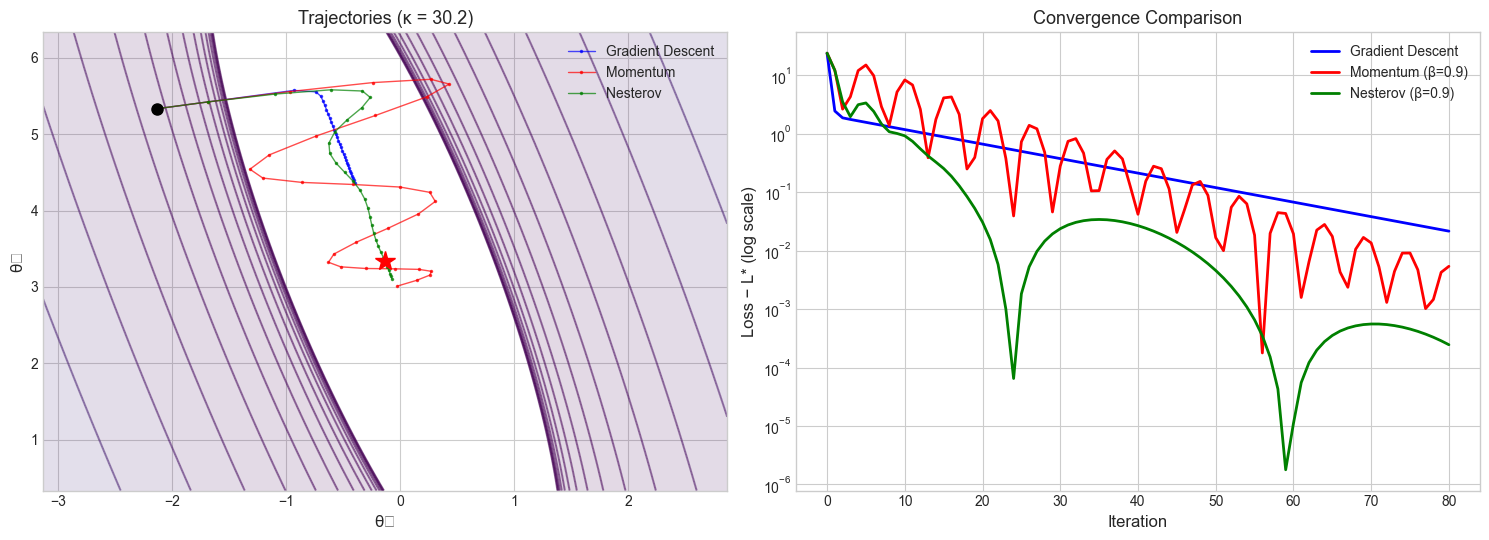

After 80 iterations:
  GD          : distance = 0.247765, excess loss = 2.16e-02
  Momentum    : distance = 0.040643, excess loss = 5.41e-03
  Nesterov    : distance = 0.026441, excess loss = 2.46e-04


In [11]:
# Compare all three methods on the ill-conditioned problem
A_hard = np.array([[20.0, 5.0],
                    [5.0, 2.0]])
b_hard = np.array([-14.0, -6.0])
theta_opt_hard = -np.linalg.solve(A_hard, b_hard)
kappa_hard = np.linalg.eigvalsh(A_hard).max() / np.linalg.eigvalsh(A_hard).min()

start_hard = theta_opt_hard + np.array([-2.0, 2.0])
n_steps = 80

path_plain = gradient_descent(quadratic_grad, start_hard, lr=0.04, n_steps=n_steps, A=A_hard, b=b_hard)
path_mom = gd_momentum(quadratic_grad, start_hard, lr=0.015, beta=0.9, n_steps=n_steps, A=A_hard, b=b_hard)
path_nag = gd_nesterov(quadratic_grad, start_hard, lr=0.015, beta=0.9, n_steps=n_steps, A=A_hard, b=b_hard)

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

opt_loss_hard = quadratic_loss(theta_opt_hard, A_hard, b_hard, 0)

# Left: trajectories
ax = axes[0]
t1_h = np.linspace(theta_opt_hard[0] - 3, theta_opt_hard[0] + 3, 200)
t2_h = np.linspace(theta_opt_hard[1] - 3, theta_opt_hard[1] + 3, 200)
T1_h, T2_h = np.meshgrid(t1_h, t2_h)
Z_h = np.zeros_like(T1_h)
for i in range(T1_h.shape[0]):
    for j in range(T1_h.shape[1]):
        th = np.array([T1_h[i, j], T2_h[i, j]])
        Z_h[i, j] = quadratic_loss(th, A_hard, b_hard, 0)

levels_h = np.logspace(-1, 3, 20)
ax.contour(T1_h, T2_h, Z_h, levels=levels_h, cmap='viridis', alpha=0.5)
ax.contourf(T1_h, T2_h, Z_h, levels=levels_h, cmap='viridis', alpha=0.15)

ax.plot(path_plain[:30, 0], path_plain[:30, 1], 'b.-', markersize=3, linewidth=1, alpha=0.7, label='Gradient Descent')
ax.plot(path_mom[:30, 0], path_mom[:30, 1], 'r.-', markersize=3, linewidth=1, alpha=0.7, label='Momentum')
ax.plot(path_nag[:30, 0], path_nag[:30, 1], 'g.-', markersize=3, linewidth=1, alpha=0.7, label='Nesterov')
ax.plot(*start_hard, 'ko', markersize=8)
ax.plot(*theta_opt_hard, 'r*', markersize=15)
ax.set_xlabel('θ₁', fontsize=12)
ax.set_ylabel('θ₂', fontsize=12)
ax.set_title(f'Trajectories (κ = {kappa_hard:.1f})', fontsize=13)
ax.legend(fontsize=10)

# Right: loss curves
ax = axes[1]
for path_i, label, color in [(path_plain, 'Gradient Descent', 'blue'), 
                              (path_mom, 'Momentum (β=0.9)', 'red'),
                              (path_nag, 'Nesterov (β=0.9)', 'green')]:
    losses = [quadratic_loss(p, A_hard, b_hard, 0) for p in path_i]
    ax.semilogy(np.array(losses) - opt_loss_hard + 1e-16, linewidth=2, color=color, label=label)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss − L* (log scale)', fontsize=12)
ax.set_title('Convergence Comparison', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"After {n_steps} iterations:")
for path_i, name in [(path_plain, 'GD'), (path_mom, 'Momentum'), (path_nag, 'Nesterov')]:
    dist = np.linalg.norm(path_i[-1] - theta_opt_hard)
    loss = quadratic_loss(path_i[-1], A_hard, b_hard, 0) - opt_loss_hard
    print(f"  {name:12s}: distance = {dist:.6f}, excess loss = {loss:.2e}")

## 7. Application: Drug Dose-Response Curve Fitting

Now let's apply these methods to a real-world biotech problem: fitting a **4-parameter logistic (4PL) dose-response curve**.

The model predicts cell viability $y$ as a function of drug concentration $x$:

$$y = d + \frac{a - d}{1 + (x / c)^b}$$

Parameters:
- $a$: upper asymptote (maximum viability)
- $d$: lower asymptote (minimum viability)
- $c$: IC50 (concentration for 50% effect)
- $b$: Hill slope (steepness of the curve)

We minimize the mean squared error:

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^{N} \left(y_n - f(x_n; \boldsymbol{\theta})\right)^2$$

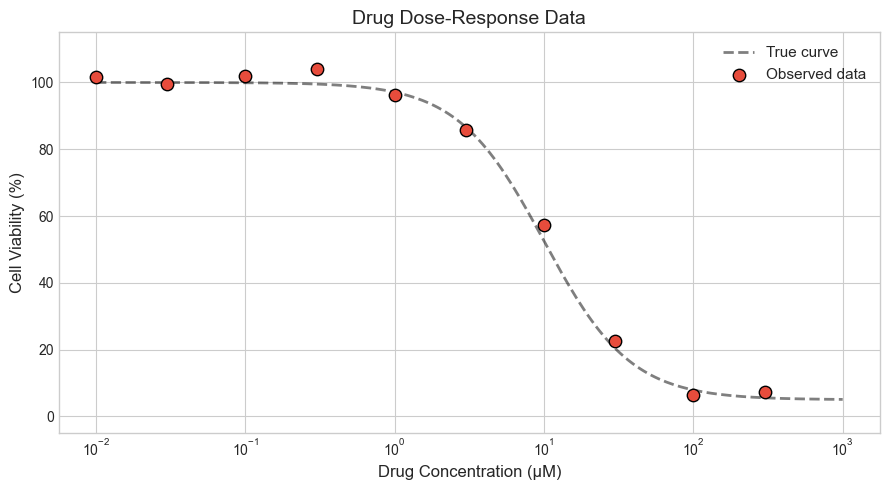

In [12]:
# Generate synthetic dose-response data
true_a = 100.0   # upper asymptote (100% viability)
true_d = 5.0     # lower asymptote (5% viability at high dose)
true_c = 10.0    # IC50 = 10 μM
true_b = 1.5     # Hill slope

def dose_response(x, a, d, c_param, b_param):
    """4-parameter logistic model."""
    return d + (a - d) / (1 + (x / c_param) ** b_param)

# Generate data with noise
np.random.seed(42)
x_data = np.array([0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0])
y_true = dose_response(x_data, true_a, true_d, true_c, true_b)
y_data = y_true + np.random.normal(0, 3.0, len(x_data))
y_data = np.clip(y_data, 0, 110)  # Keep within reasonable bounds

# Plot the data
fig, ax = plt.subplots(figsize=(9, 5))
x_dense = np.logspace(-2, 3, 200)
ax.plot(x_dense, dose_response(x_dense, true_a, true_d, true_c, true_b), 
        'k--', linewidth=2, label='True curve', alpha=0.5)
ax.scatter(x_data, y_data, s=80, c='#e74c3c', edgecolors='black', zorder=5, label='Observed data')
ax.set_xscale('log')
ax.set_xlabel('Drug Concentration (μM)', fontsize=12)
ax.set_ylabel('Cell Viability (%)', fontsize=12)
ax.set_title('Drug Dose-Response Data', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(-5, 115)
plt.tight_layout()
plt.show()

In [13]:
# We optimize in log-space for c (IC50) and work with transformed parameters
# theta = [a, d, log(c), b]

def loss_dose_response(theta, x=x_data, y=y_data):
    """MSE loss for dose-response fitting."""
    a, d, log_c, b_param = theta
    c_param = np.exp(log_c)
    y_pred = dose_response(x, a, d, c_param, b_param)
    return np.mean((y - y_pred)**2)

def grad_dose_response(theta, x=x_data, y=y_data, eps=1e-5):
    """Numerical gradient of the dose-response loss."""
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        theta_plus = theta.copy()
        theta_minus = theta.copy()
        theta_plus[i] += eps
        theta_minus[i] -= eps
        grad[i] = (loss_dose_response(theta_plus, x, y) - loss_dose_response(theta_minus, x, y)) / (2 * eps)
    return grad

# Initial guess (deliberately off)
theta0_dr = np.array([80.0, 20.0, np.log(5.0), 1.0])  # a=80, d=20, c=5, b=1
print(f"Initial parameters: a={theta0_dr[0]:.0f}, d={theta0_dr[1]:.0f}, "
      f"c={np.exp(theta0_dr[2]):.1f}, b={theta0_dr[3]:.1f}")
print(f"Initial loss: {loss_dose_response(theta0_dr):.2f}")

Initial parameters: a=80, d=20, c=5.0, b=1.0
Initial loss: 444.09


In [14]:
def gd_backtracking_general(loss_fn, grad_fn, theta0, n_steps, rho=0.5, c_armijo=1e-4, eta_init=1.0, **kwargs):
    """Gradient descent with Armijo backtracking (general version)."""
    theta = theta0.copy().astype(float)
    path = [theta.copy()]
    losses = [loss_fn(theta, **kwargs)]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        d = -g
        eta = eta_init
        current_loss = losses[-1]
        for _ in range(50):  # max backtracking iterations
            new_loss = loss_fn(theta + eta * d, **kwargs)
            if new_loss <= current_loss + c_armijo * eta * (d @ g):
                break
            eta *= rho
        theta = theta + eta * d
        path.append(theta.copy())
        losses.append(loss_fn(theta, **kwargs))
    return np.array(path), np.array(losses)

def gd_fixed_general(loss_fn, grad_fn, theta0, lr, n_steps, **kwargs):
    """Gradient descent with fixed step size (general version)."""
    theta = theta0.copy().astype(float)
    path = [theta.copy()]
    losses = [loss_fn(theta, **kwargs)]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        theta = theta - lr * g
        path.append(theta.copy())
        losses.append(loss_fn(theta, **kwargs))
    return np.array(path), np.array(losses)

def momentum_general(loss_fn, grad_fn, theta0, lr, beta, n_steps, **kwargs):
    """Momentum method (general version)."""
    theta = theta0.copy().astype(float)
    m = np.zeros_like(theta)
    path = [theta.copy()]
    losses = [loss_fn(theta, **kwargs)]
    for _ in range(n_steps):
        g = grad_fn(theta, **kwargs)
        m = beta * m + g
        theta = theta - lr * m
        path.append(theta.copy())
        losses.append(loss_fn(theta, **kwargs))
    return np.array(path), np.array(losses)

def nesterov_general(loss_fn, grad_fn, theta0, lr, beta, n_steps, **kwargs):
    """Nesterov accelerated gradient (general version)."""
    theta = theta0.copy().astype(float)
    m = np.zeros_like(theta)
    path = [theta.copy()]
    losses = [loss_fn(theta, **kwargs)]
    for _ in range(n_steps):
        theta_ahead = theta + beta * m
        g = grad_fn(theta_ahead, **kwargs)
        m = beta * m - lr * g
        theta = theta + m
        path.append(theta.copy())
        losses.append(loss_fn(theta, **kwargs))
    return np.array(path), np.array(losses)

# Run optimizers on the dose-response problem
n_steps_dr = 800

# Backtracking adapts step size automatically — the most robust method
path_bt, losses_bt = gd_backtracking_general(
    loss_dose_response, grad_dose_response, theta0_dr, n_steps_dr)

# Fixed step size — requires careful tuning
path_fixed_dr, losses_fixed_dr = gd_fixed_general(
    loss_dose_response, grad_dose_response, theta0_dr, lr=0.005, n_steps=n_steps_dr)

# Momentum accelerates convergence
path_mom_dr, losses_mom_dr = momentum_general(
    loss_dose_response, grad_dose_response, theta0_dr, 
    lr=0.005, beta=0.8, n_steps=n_steps_dr)

# Nesterov with look-ahead
path_nag_dr, losses_nag_dr = nesterov_general(
    loss_dose_response, grad_dose_response, theta0_dr,
    lr=0.003, beta=0.8, n_steps=n_steps_dr)

print("Final losses:")
print(f"  Backtracking GD:  {losses_bt[-1]:.4f}")
print(f"  Fixed η GD:       {losses_fixed_dr[-1]:.4f}")
print(f"  Momentum (β=0.8): {losses_mom_dr[-1]:.4f}")
print(f"  Nesterov (β=0.8): {losses_nag_dr[-1]:.4f}")

Final losses:
  Backtracking GD:  5.9693
  Fixed η GD:       6.3997
  Momentum (β=0.8): 3.0848
  Nesterov (β=0.8): 3.1269


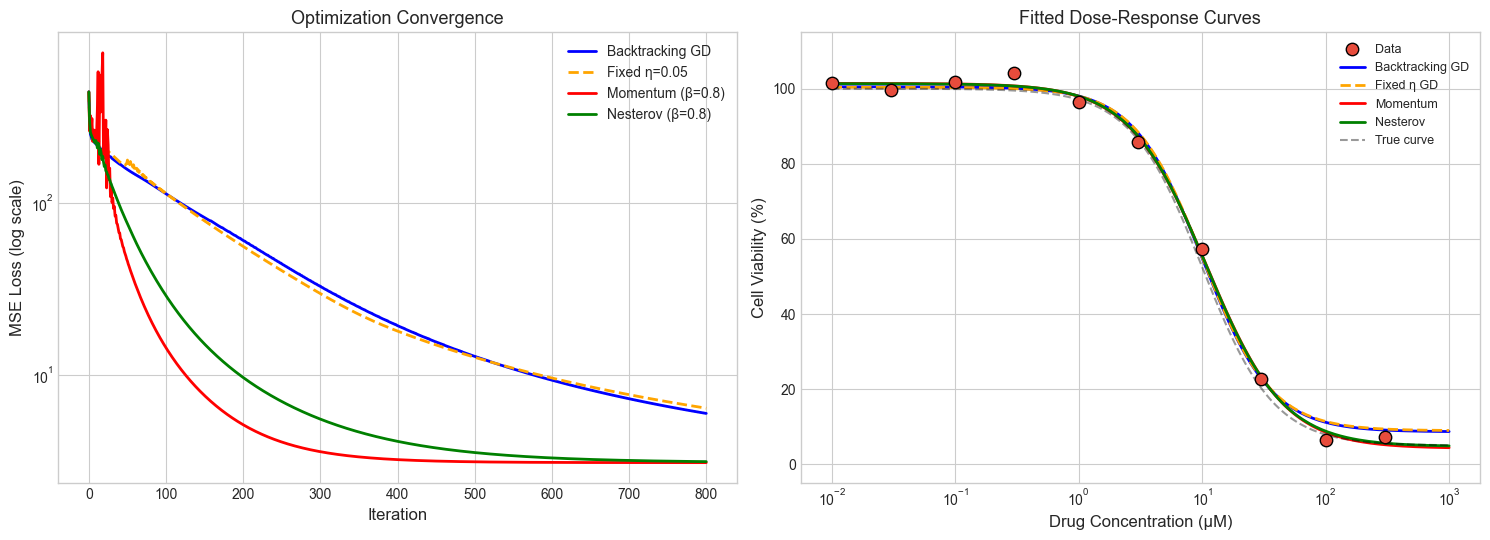

In [15]:
# Plot convergence and final fits
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: convergence curves
ax = axes[0]
ax.semilogy(losses_bt, linewidth=2, label='Backtracking GD', color='blue')
ax.semilogy(losses_fixed_dr, linewidth=2, label='Fixed η=0.05', color='orange', linestyle='--')
ax.semilogy(losses_mom_dr, linewidth=2, label='Momentum (β=0.8)', color='red')
ax.semilogy(losses_nag_dr, linewidth=2, label='Nesterov (β=0.8)', color='green')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('MSE Loss (log scale)', fontsize=12)
ax.set_title('Optimization Convergence', fontsize=13)
ax.legend(fontsize=10)

# Right: fitted curves
ax = axes[1]
ax.scatter(x_data, y_data, s=80, c='#e74c3c', edgecolors='black', zorder=5, label='Data')

x_dense = np.logspace(-2, 3, 200)
for path_i, label, color, ls in [(path_bt, 'Backtracking GD', 'blue', '-'), 
                                   (path_fixed_dr, 'Fixed η GD', 'orange', '--'),
                                   (path_mom_dr, 'Momentum', 'red', '-'),
                                   (path_nag_dr, 'Nesterov', 'green', '-')]:
    theta_final = path_i[-1]
    a_f, d_f, log_c_f, b_f = theta_final
    y_fit = dose_response(x_dense, a_f, d_f, np.exp(log_c_f), b_f)
    ax.plot(x_dense, y_fit, linewidth=2, color=color, linestyle=ls, label=label)

ax.plot(x_dense, dose_response(x_dense, true_a, true_d, true_c, true_b),
        'k--', linewidth=1.5, alpha=0.4, label='True curve')
ax.set_xscale('log')
ax.set_xlabel('Drug Concentration (μM)', fontsize=12)
ax.set_ylabel('Cell Viability (%)', fontsize=12)
ax.set_title('Fitted Dose-Response Curves', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(-5, 115)

plt.tight_layout()
plt.show()

In [16]:
# Print fitted parameters
print("Fitted Parameters Comparison")
print("=" * 65)
print(f"{'Method':<20} {'a':>8} {'d':>8} {'IC50':>8} {'b':>8} {'MSE':>8}")
print("-" * 65)
print(f"{'True':.<20} {true_a:>8.1f} {true_d:>8.1f} {true_c:>8.1f} {true_b:>8.2f} {'—':>8}")

for path_i, name in [(path_bt, 'Backtracking GD'), 
                      (path_fixed_dr, 'Fixed η GD'),
                      (path_mom_dr, 'Momentum'),
                      (path_nag_dr, 'Nesterov')]:
    a_f, d_f, log_c_f, b_f = path_i[-1]
    mse = loss_dose_response(path_i[-1])
    print(f"{name:.<20} {a_f:>8.1f} {d_f:>8.1f} {np.exp(log_c_f):>8.1f} {b_f:>8.2f} {mse:>8.2f}")

Fitted Parameters Comparison
Method                      a        d     IC50        b      MSE
-----------------------------------------------------------------
True................    100.0      5.0     10.0     1.50        —
Backtracking GD.....    100.5      8.7     10.1     1.55     5.97
Fixed η GD..........    100.4      9.0     10.1     1.57     6.40
Momentum............    101.4      4.2     10.9     1.38     3.08
Nesterov............    101.3      4.7     10.8     1.40     3.13


## 8. Summary

### Key Formulas

| Method | Update Rule | Key Property |
|--------|-----------|---------------|
| **Steepest Descent** | $\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \nabla\mathcal{L}(\boldsymbol{\theta}_t)$ | Simple; can zig-zag |
| **Exact Line Search** | $\eta_t = \operatorname*{argmin}_\eta \mathcal{L}(\boldsymbol{\theta}_t - \eta \mathbf{g}_t)$ | Optimal step; orthogonal steps |
| **Armijo Backtracking** | Reduce $\eta$ until $\mathcal{L}(\boldsymbol{\theta} + \eta\mathbf{d}) \leq \mathcal{L}(\boldsymbol{\theta}) + c\eta\mathbf{d}^\top\mathbf{g}$ | Practical; sufficient decrease |
| **Momentum** | $\mathbf{m}_t = \beta\mathbf{m}_{t-1} + \mathbf{g}_t$; $\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \eta\mathbf{m}_t$ | Accelerates along consistent directions |
| **Nesterov** | Evaluate gradient at $\boldsymbol{\theta}_t + \beta\mathbf{m}_t$ | "Look-ahead"; provably faster |

### Convergence Rates

For a quadratic with condition number $\kappa$:
- **Steepest descent**: $\mu = \left(\frac{\kappa - 1}{\kappa + 1}\right)^2$ — degrades with ill-conditioning
- **Momentum/Nesterov**: Can achieve $\mu = \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}$ — much better for large $\kappa$

### Practical Takeaways

1. **Step size matters**: Too large causes oscillation/divergence; too small wastes computation
2. **Line search** removes the need to tune $\eta$ but adds per-step cost
3. **Condition number** determines convergence speed — ill-conditioned problems benefit greatly from momentum
4. **Nesterov momentum** provides a principled acceleration and is the default choice in many modern optimizers